In [2]:
import pandas as pd

df = pd.read_csv("Delivery_Logistics.csv")

print(df.head())
print(df.shape)
print(df.columns)
print(df.info())
print(df.describe())

   delivery_id delivery_partner      package_type vehicle_type delivery_mode  \
0       250.99        delhivery  automobile parts         bike      same day   
1       250.99       xpressbees         cosmetics       ev van       express   
2       250.99        shadowfax         groceries        truck       two day   
3       250.99              dhl       electronics       ev van      same day   
4       250.99              dhl          clothing          van       two day   

    region weather_condition  distance_km  package_weight_kg  \
0     west             clear        297.0              46.96   
1  central              cold         89.6              47.39   
2     east             rainy        273.5              26.89   
3     east              cold        269.7              12.69   
4    north             foggy        256.7              37.02   

             delivery_time_hours            expected_time_hours delayed  \
0  1970-01-01 00:00:00.000000008  1970-01-01 00:00:00.00000

In [3]:
df.isnull().sum()

,0
delivery_id,0
delivery_partner,0
package_type,0
vehicle_type,0
delivery_mode,0
region,0
weather_condition,0
distance_km,0
package_weight_kg,0
delivery_time_hours,0


In [4]:
df.duplicated().sum()

df = df.drop_duplicates()

In [7]:
df["delivery_time_hours"] = pd.to_datetime(df["delivery_time_hours"]).dt.nanosecond
df["expected_time_hours"] = pd.to_datetime(df["expected_time_hours"]).dt.nanosecond

In [8]:
total_deliveries = len(df)

on_time = (df["delayed"] == "no").sum()

on_time_rate = (on_time / total_deliveries) * 100

print("On-Time Delivery Rate:", on_time_rate)

On-Time Delivery Rate: 73.324


In [9]:
average_shipping_cost = df["delivery_cost"].mean()

print("Average Shipping Cost:", average_shipping_cost)

Average Shipping Cost: 864.9445787999999


In [10]:
df["Delivery Time"] = df["delivery_time_hours"]

average_delivery_time = df["Delivery Time"].mean()

print("Average Delivery Time:", average_delivery_time)

Average Delivery Time: 6.24804


In [11]:
df.groupby("delivery_mode")["Delivery Time"].mean()

,Delivery Time
delivery_mode,
express,6.230868
same day,6.244784
standard,6.237472
two day,6.278642


In [13]:
df['Is_Late_Delivery'] = df['delayed'].apply(lambda x: 1 if x == 'yes' else 0)
df.groupby("region")["Is_Late_Delivery"].mean()

,Is_Late_Delivery
region,
central,0.272530
east,0.257979
north,0.265710
south,0.267832
west,0.269480


In [14]:
df.groupby("delivery_mode")["delivery_cost"].mean()

,delivery_cost
delivery_mode,
express,880.426426
same day,929.872468
standard,819.335575
two day,829.710800


In [15]:
df[["distance_km", "Delivery Time"]].corr()

,distance_km,Delivery Time
distance_km,1.000000,0.685883
Delivery Time,0.685883,1.000000


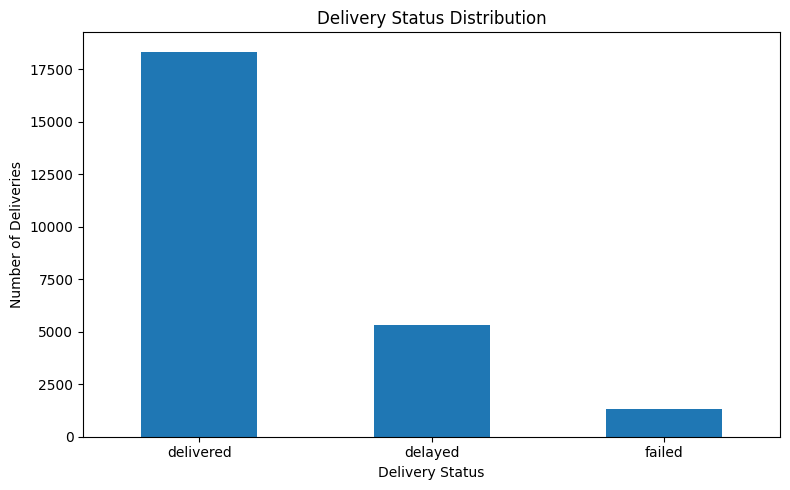

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("Delivery_Logistics.csv")

# Count deliveries by status
status_counts = df["delivery_status"].value_counts()

# Create bar chart
plt.figure(figsize=(8, 5))

status_counts.plot(kind="bar")

plt.title("Delivery Status Distribution")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Deliveries")

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

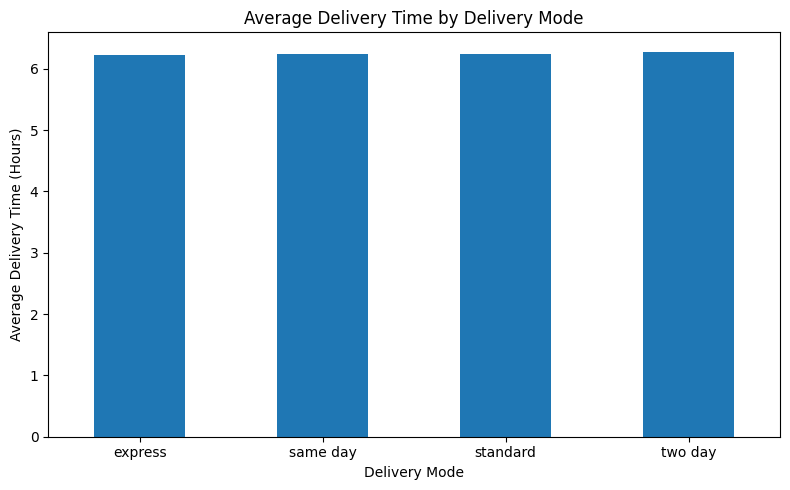

In [17]:
# Calculate average delivery time by delivery mode
df["delivery_time_hours"] = df["delivery_time_hours"].astype(str).str.split('.').str[-1].astype(float)
avg_time = df.groupby("delivery_mode")["delivery_time_hours"].mean()

# Create bar chart
plt.figure(figsize=(8, 5))

avg_time.plot(kind="bar")

plt.title("Average Delivery Time by Delivery Mode")
plt.xlabel("Delivery Mode")
plt.ylabel("Average Delivery Time (Hours)")

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

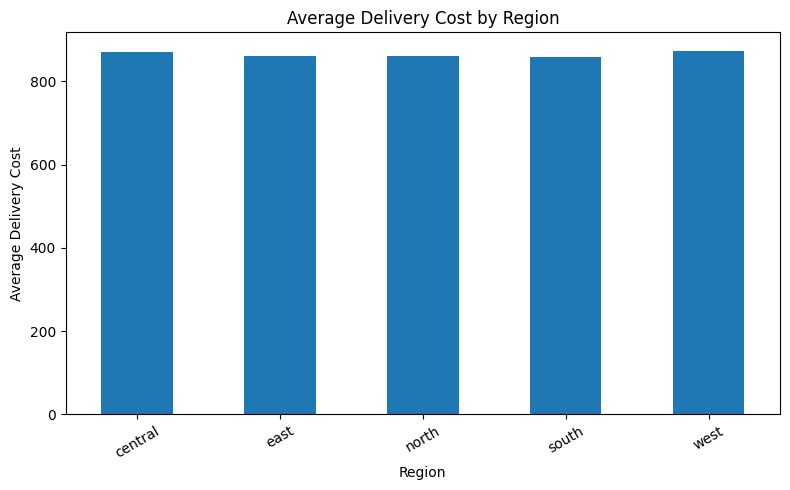

In [18]:
# Calculate average delivery cost by region
avg_cost = df.groupby("region")["delivery_cost"].mean()

# Create bar chart
plt.figure(figsize=(8, 5))

avg_cost.plot(kind="bar")

plt.title("Average Delivery Cost by Region")
plt.xlabel("Region")
plt.ylabel("Average Delivery Cost")

plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

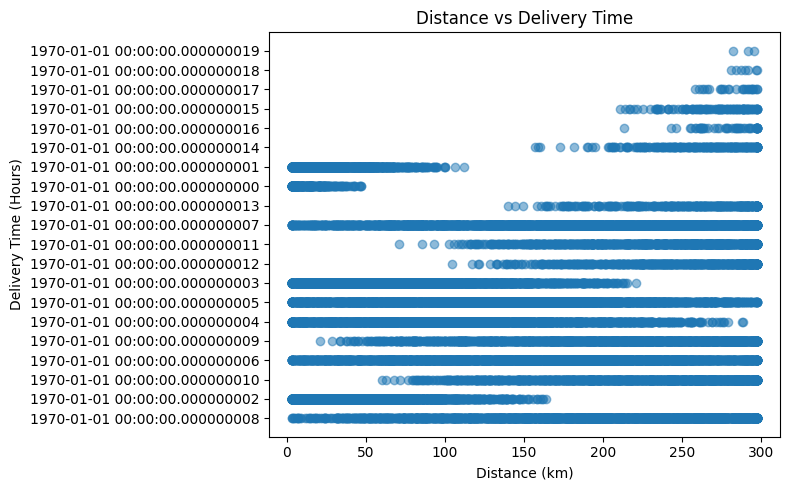

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("Delivery_Logistics.csv")

# Create scatter plot
plt.figure(figsize=(8, 5))

plt.scatter(
    df["distance_km"],
    df["delivery_time_hours"],
    alpha=0.5
)

plt.title("Distance vs Delivery Time")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (Hours)")

plt.tight_layout()
plt.show()

In [20]:
print(df.columns.tolist())

['delivery_id', 'delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode', 'region', 'weather_condition', 'distance_km', 'package_weight_kg', 'delivery_time_hours', 'expected_time_hours', 'delayed', 'delivery_status', 'delivery_rating', 'delivery_cost']


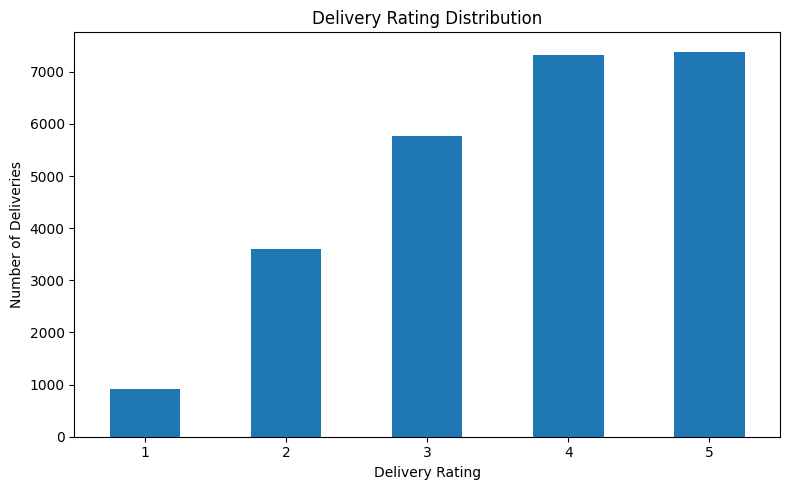

In [21]:
rating_counts = df["delivery_rating"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
rating_counts.plot(kind="bar")

plt.title("Delivery Rating Distribution")
plt.xlabel("Delivery Rating")
plt.ylabel("Number of Deliveries")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

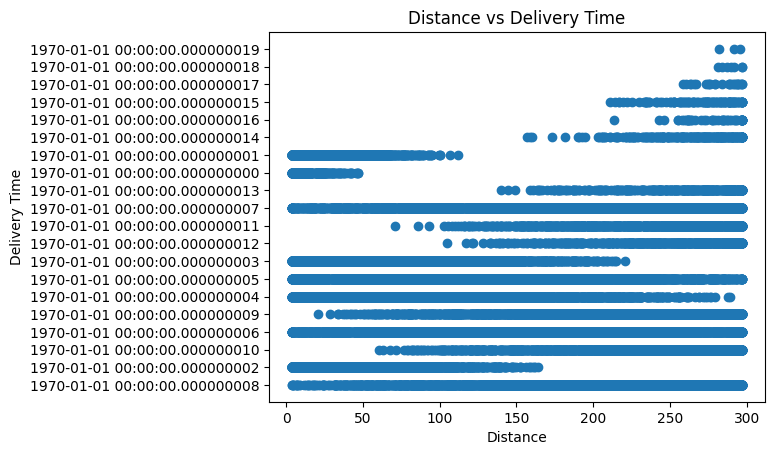

In [22]:
import matplotlib.pyplot as plt

plt.scatter(df["distance_km"], df["delivery_time_hours"])

plt.xlabel("Distance")
plt.ylabel("Delivery Time")
plt.title("Distance vs Delivery Time")

plt.show()

In [23]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("Delivery_Logistics.csv")

# ---------------------------------------
# CONVERT DELIVERY TIME TO HOURS
# ---------------------------------------

df["delivery_time_hours"] = (
    pd.to_datetime(df["delivery_time_hours"])
    .dt.nanosecond
)

# ---------------------------------------
# CONVERT EXPECTED TIME TO HOURS
# ---------------------------------------

df["expected_time_hours"] = (
    pd.to_datetime(df["expected_time_hours"])
    .dt.nanosecond
)

# Check the result
print(df[[
    "delivery_time_hours",
    "expected_time_hours"
]].head())

print(df[[
    "delivery_time_hours",
    "expected_time_hours"
]].describe())

   delivery_time_hours  expected_time_hours
0                    8                    8
1                    2                    3
2                   10                   16
3                    6                    8
4                    9                   16
       delivery_time_hours  expected_time_hours
count         25000.000000         25000.000000
mean              6.248040            13.107680
std               3.140935             7.559024
min               0.000000             2.000000
25%               4.000000             8.000000
50%               6.000000             8.000000
75%               8.000000            16.000000
max              19.000000            24.000000


In [24]:
# Calculate actual delay in hours
df["delay_hours"] = (
    df["delivery_time_hours"] -
    df["expected_time_hours"]
)

print(df[[
    "delivery_time_hours",
    "expected_time_hours",
    "delay_hours"
]].head())

   delivery_time_hours  expected_time_hours  delay_hours
0                    8                    8            0
1                    2                    3           -1
2                   10                   16           -6
3                    6                    8           -2
4                    9                   16           -7


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# ---------------------------------------
# FEATURES AND TARGET
# ---------------------------------------

X = df[
    [
        "distance_km",
        "package_weight_kg",
        "expected_time_hours",
        "delivery_partner",
        "package_type",
        "vehicle_type",
        "delivery_mode",
        "region",
        "weather_condition"
    ]
]

y = df["delivery_time_hours"]

# ---------------------------------------
# NUMERICAL AND CATEGORICAL COLUMNS
# ---------------------------------------

numeric_features = [
    "distance_km",
    "package_weight_kg",
    "expected_time_hours"
]

categorical_features = [
    "delivery_partner",
    "package_type",
    "vehicle_type",
    "delivery_mode",
    "region",
    "weather_condition"
]

# ---------------------------------------
# PREPROCESSING
# ---------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(strategy="median"),
            numeric_features
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        )
    ]
)

# ---------------------------------------
# MODEL
# ---------------------------------------

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", model)
])

# ---------------------------------------
# TRAIN / TEST SPLIT
# ---------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Train model
pipeline.fit(X_train, y_train)

# Predictions
y_pred = pipeline.predict(X_test)

# ---------------------------------------
# EVALUATION
# ---------------------------------------

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Mean Absolute Error: 1.3260219999999998
Root Mean Squared Error: 1.6752975079071777
R² Score: 0.710268907887744


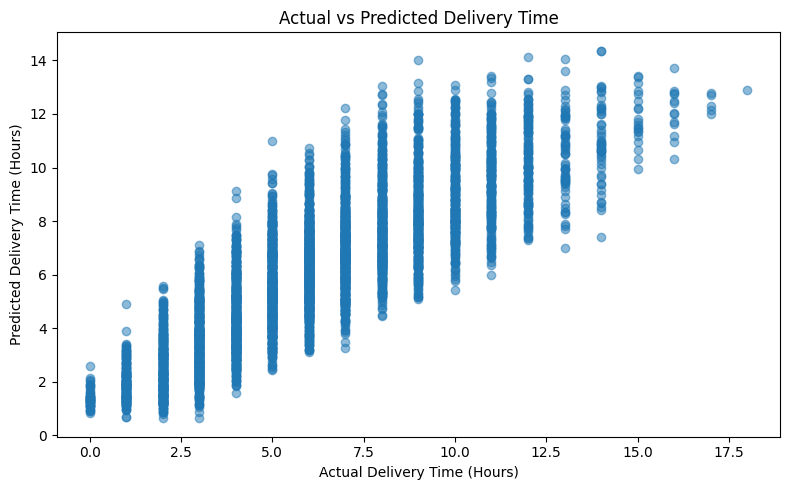

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Delivery Time (Hours)")
plt.ylabel("Predicted Delivery Time (Hours)")
plt.title("Actual vs Predicted Delivery Time")

plt.tight_layout()
plt.show()

In [28]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select numerical logistics variables
cluster_data = df[
    [
        "distance_km",
        "package_weight_kg",
        "delivery_time_hours",
        "expected_time_hours",
        "delivery_cost"
    ]
].copy()

# Remove missing values
cluster_data = cluster_data.dropna()

# Standardize the variables
scaler = StandardScaler()

scaled_data = scaler.fit_transform(cluster_data)

# ---------------------------------------
# K-MEANS CLUSTERING
# ---------------------------------------

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(scaled_data)

# Add cluster labels
cluster_data["Cluster"] = clusters

print(cluster_data.head())

   distance_km  package_weight_kg  delivery_time_hours  expected_time_hours  \
0        297.0              46.96                    8                    8   
1         89.6              47.39                    2                    3   
2        273.5              26.89                   10                   16   
3        269.7              12.69                    6                    8   
4        256.7              37.02                    9                   16   

   delivery_cost  Cluster  
0      1632.7206        0  
1       640.1700        1  
2      1448.1700        0  
3      1486.5700        0  
4      1394.5600        0  


In [29]:
cluster_summary = cluster_data.groupby("Cluster")[
    [
        "distance_km",
        "package_weight_kg",
        "delivery_time_hours",
        "expected_time_hours",
        "delivery_cost"
    ]
].mean()

print(cluster_summary)

         distance_km  package_weight_kg  delivery_time_hours  \
Cluster                                                        
0         231.922110          25.800250             8.598266   
1          85.089269          24.605139             4.318453   
2          86.053099          24.645799             4.439512   

         expected_time_hours  delivery_cost  
Cluster                                      
0                  13.243046    1275.266397  
1                   5.561873     573.355320  
2                  20.254716     505.020619  


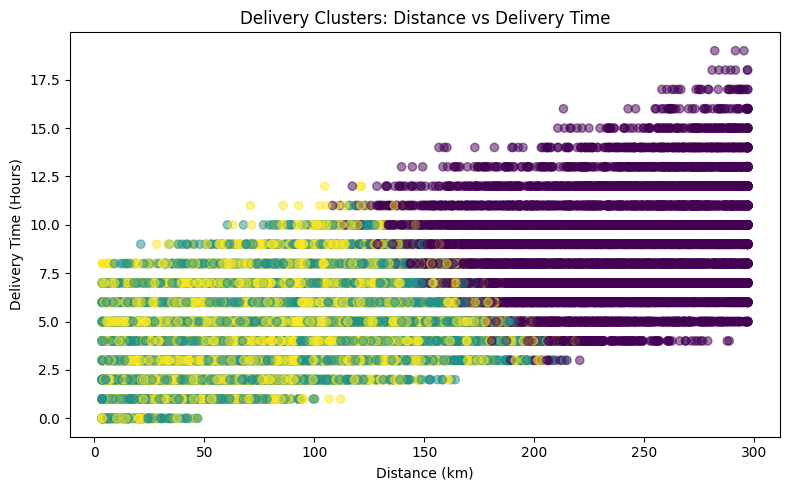

In [30]:
plt.figure(figsize=(8, 5))

plt.scatter(
    cluster_data["distance_km"],
    cluster_data["delivery_time_hours"],
    c=cluster_data["Cluster"],
    alpha=0.5
)

plt.title("Delivery Clusters: Distance vs Delivery Time")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (Hours)")

plt.tight_layout()
plt.show()

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# ---------------------------------------
# FEATURES
# ---------------------------------------

X = df[
    [
        "distance_km",
        "package_weight_kg",
        "expected_time_hours",
        "delivery_partner",
        "package_type",
        "vehicle_type",
        "delivery_mode",
        "region",
        "weather_condition"
    ]
]

# Convert yes/no to 1/0
y = df["delayed"].map({
    "yes": 1,
    "no": 0
})

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(strategy="median"),
            numeric_features
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        )
    ]
)

# Classification model
classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

classification_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", classifier)
])

# Train
classification_pipeline.fit(X_train, y_train)

# Predict
y_pred = classification_pipeline.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8894

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.92      3666
           1       0.79      0.80      0.79      1334

    accuracy                           0.89      5000
   macro avg       0.86      0.86      0.86      5000
weighted avg       0.89      0.89      0.89      5000

